# Análisis Global de Clima y Energía 2020–2024

---

| | |
|---|---|
| **Autor** | Miguel Sierra |
| **Fecha** | 2025 |
| **Dataset** | Global Climate & Energy 2020–2024 |
| **Registros** | 36,540 · 20 países · 5 años · 10 variables |
| **Herramientas** | Python · Pandas · Plotly · Scikit-learn · MySQL |

---

## Tabla de contenidos

1. [Configuración y carga de datos](#seccion1)
2. [Exploración y calidad del dato](#seccion2)
3. [Estadística descriptiva](#seccion3)
4. [Visualizaciones interactivas](#seccion4)
5. [Análisis de correlación y regresión](#seccion5)
6. [Conclusiones y hallazgos finales](#seccion6)

---

> **Nota metodológica:** El dataset utilizado es de naturaleza sintética,
> generado para práctica de análisis de datos. Las técnicas aplicadas
> son válidas y replicables sobre datos reales.

---
## 1. Configuración y carga de datos
<a id="seccion1"></a>

In [1]:
# ── Librerías ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# ── Configuración visual ───────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["figure.dpi"]     = 120

# ── Carga del dataset ──────────────────────────────────
df = pd.read_csv("../data/dataset_limpio.csv", parse_dates=["date"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

# ── Regiones ───────────────────────────────────────────
regiones = {
    "Germany":"Europa","France":"Europa","United Kingdom":"Europa",
    "Italy":"Europa","Spain":"Europa","Sweden":"Europa",
    "Norway":"Europa","Netherlands":"Europa","Poland":"Europa",
    "Turkey":"Europa",
    "United States":"America","Canada":"America",
    "Mexico":"America","Brazil":"America",
    "China":"Asia-Pacifico","India":"Asia-Pacifico",
    "Japan":"Asia-Pacifico","Indonesia":"Asia-Pacifico",
    "Australia":"Asia-Pacifico",
    "South Africa":"Africa"
}
df["region"] = df["country"].map(regiones)

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"   Países  : {df['country'].nunique()}")
print(f"   Período : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Regiones: {sorted(df['region'].unique())}")

✅ Dataset cargado: 36,540 filas × 13 columnas
   Países  : 20
   Período : 2020-01-01 → 2024-12-31
   Regiones: ['Africa', 'America', 'Asia-Pacifico', 'Europa']


---
## 2. Exploración y calidad del dato
<a id="seccion2"></a>

**Objetivo:** Verificar la estructura del dataset, detectar valores nulos
y entender la distribución de cada variable antes del análisis.

In [2]:
# ── Resumen de calidad ─────────────────────────────────
print("=" * 60)
print("RESUMEN DE CALIDAD DEL DATASET")
print("=" * 60)

nulos = df.isnull().sum()
print(f"\n  Valores nulos     : {nulos.sum()}")
print(f"  Filas duplicadas  : {df.duplicated().sum()}")
print(f"  Rango de fechas   : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Registros/país    : {df.groupby('country').size().unique()[0]}")

print(f"\n{'VARIABLE':<30} {'MIN':>8} {'MEDIA':>8} {'MAX':>8} {'STD':>8}")
print("-" * 60)
variables = ["avg_temperature","humidity","co2_emission",
             "energy_consumption","renewable_share",
             "urban_population","industrial_activity_index","energy_price"]
for v in variables:
    print(f"  {v:<28} {df[v].min():>8.2f} {df[v].mean():>8.2f} "
          f"{df[v].max():>8.2f} {df[v].std():>8.2f}")

RESUMEN DE CALIDAD DEL DATASET

  Valores nulos     : 0
  Filas duplicadas  : 0
  Rango de fechas   : 2020-01-01 → 2024-12-31
  Registros/país    : 1827

VARIABLE                            MIN    MEDIA      MAX      STD
------------------------------------------------------------
  avg_temperature                 -9.60    13.58    38.71    10.08
  humidity                        30.00    59.97    90.00    17.30
  co2_emission                    50.15   445.82   999.85   234.36
  energy_consumption            1001.89  7295.90 15998.05  3693.93
  renewable_share                  5.00    15.94    30.87     5.33
  urban_population                60.00    74.98    90.00     8.65
  industrial_activity_index       40.00    70.17   100.00    17.33
  energy_price                    30.00   115.28   200.00    49.18


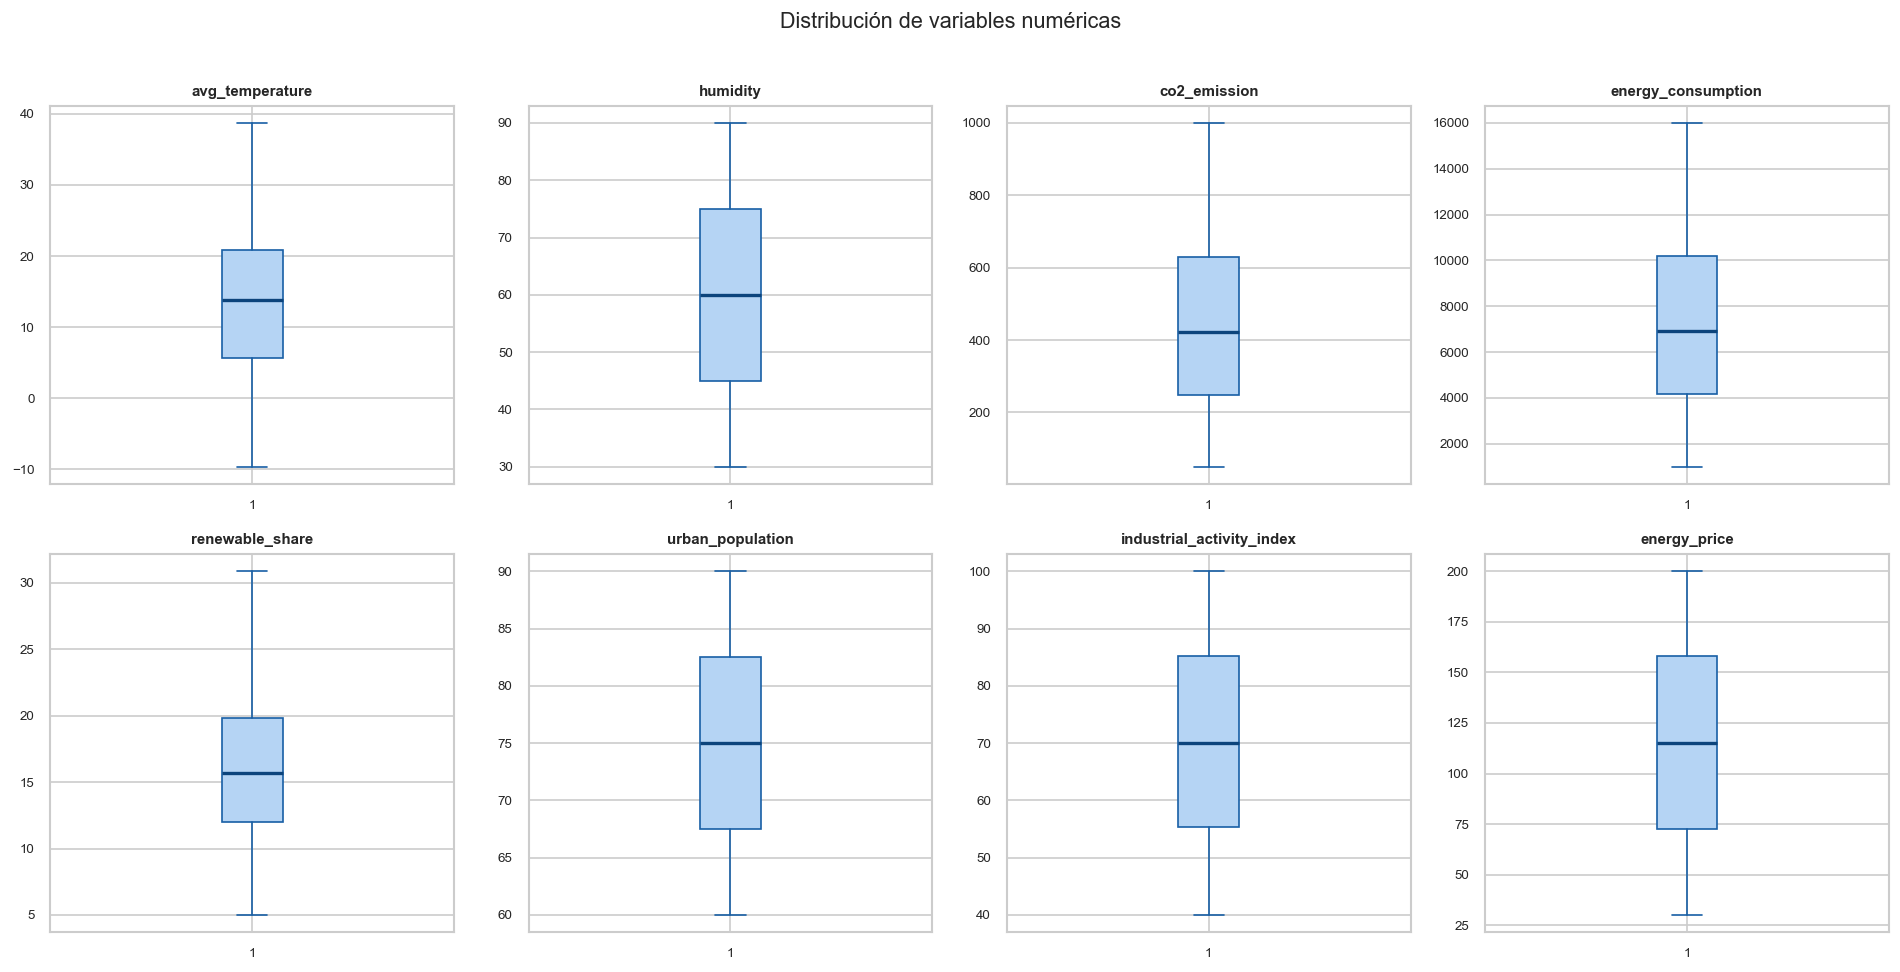

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(variables):
    axes[i].boxplot(
        df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
        medianprops=dict(color="#0C447C", linewidth=2),
        whiskerprops=dict(color="#185FA5"),
        capprops=dict(color="#185FA5"),
        flierprops=dict(marker="o", color="#E24B4A",
                       markersize=3, alpha=0.5)
    )
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=8)

plt.suptitle("Distribución de variables numéricas", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Estadística descriptiva
<a id="seccion3"></a>

**Objetivo:** Caracterizar cada variable y comparar países y regiones
mediante medidas de tendencia central, dispersión y análisis temporal.

In [4]:
temp_region = (df.groupby(["year","region"])["avg_temperature"]
               .mean().reset_index())

fig = px.line(
    temp_region, x="year", y="avg_temperature",
    color="region", markers=True,
    title="Temperatura promedio anual por región (2020–2024)",
    labels={"avg_temperature":"Temperatura (°C)","year":"Año"},
    height=420
)
fig.update_layout(xaxis=dict(tickmode="linear", dtick=1))
fig.show()

In [5]:
co2_region = (df.groupby(["year","region"])["co2_emission"]
              .mean().reset_index())

fig = px.bar(
    co2_region, x="year", y="co2_emission",
    color="region", barmode="group",
    title="Emisiones promedio de CO₂ por región y año",
    labels={"co2_emission":"CO₂ promedio","year":"Año"},
    height=420
)
fig.update_layout(xaxis=dict(tickmode="linear", dtick=1))
fig.show()

In [6]:
renov = (df.groupby(["country","region"])["renewable_share"]
         .mean().reset_index()
         .sort_values("renewable_share", ascending=True))

media_global = df["renewable_share"].mean()

fig = px.bar(
    renov, x="renewable_share", y="country",
    color="region", orientation="h",
    title="Participación renovable promedio por país (2020–2024)",
    labels={"renewable_share":"% Renovable","country":"País"},
    height=600
)
fig.add_vline(
    x=media_global, line_dash="dash",
    line_color="black", line_width=1.5,
    annotation_text=f"Promedio global: {media_global:.1f}%",
    annotation_position="top right"
)
fig.show()

In [7]:
temp_pivot = (df.groupby(["country","month"])["avg_temperature"]
              .mean().reset_index()
              .pivot(index="country", columns="month",
                     values="avg_temperature"))
temp_pivot.columns = ["Ene","Feb","Mar","Abr","May","Jun",
                       "Jul","Ago","Sep","Oct","Nov","Dic"]

fig = px.imshow(
    temp_pivot, color_continuous_scale="RdYlBu_r",
    title="Temperatura promedio por país y mes",
    labels=dict(color="°C"), aspect="auto", height=580
)
fig.show()

---
## 4. Visualizaciones interactivas
<a id="seccion4"></a>

**Objetivo:** Explorar patrones geográficos y multidimensionales
mediante mapas coropléticos y gráficos de burbujas.

In [8]:
resumen = (df.groupby(["country","region"])
           .agg(
               temp_promedio    =("avg_temperature","mean"),
               co2_promedio     =("co2_emission","mean"),
               renovable_pct    =("renewable_share","mean"),
               consumo_promedio =("energy_consumption","mean"),
               precio_energia   =("energy_price","mean")
           ).reset_index().round(2))

for metrica, titulo, escala in [
    ("co2_promedio",    "CO₂ promedio por país",          "Reds"),
    ("renovable_pct",   "% Renovable promedio por país",  "Greens"),
    ("temp_promedio",   "Temperatura promedio por país",  "RdYlBu_r"),
    ("consumo_promedio","Consumo energético por país",    "Blues")
]:
    fig = px.choropleth(
        resumen, locations="country",
        locationmode="country names",
        color=metrica,
        color_continuous_scale=escala,
        title=titulo, height=420
    )
    fig.update_layout(geo=dict(showframe=False))
    fig.show()

In [9]:
fig = px.scatter(
    resumen,
    x="renovable_pct", y="precio_energia",
    size="co2_promedio", color="region",
    text="country",
    title="Renovables vs Precio energía vs CO₂ — vista multidimensional",
    labels={
        "renovable_pct"  : "% Renovable promedio",
        "precio_energia" : "Precio energía promedio",
        "co2_promedio"   : "CO₂ promedio"
    },
    height=540, size_max=40
)
fig.update_traces(textposition="top center", textfont_size=9)
fig.show()

---
## 5. Análisis de correlación y regresión
<a id="seccion5"></a>

**Objetivo:** Identificar relaciones estadísticas entre variables
y construir un modelo de regresión lineal para la única relación
significativa detectada: CO₂ → consumo energético (r = 0.1718).

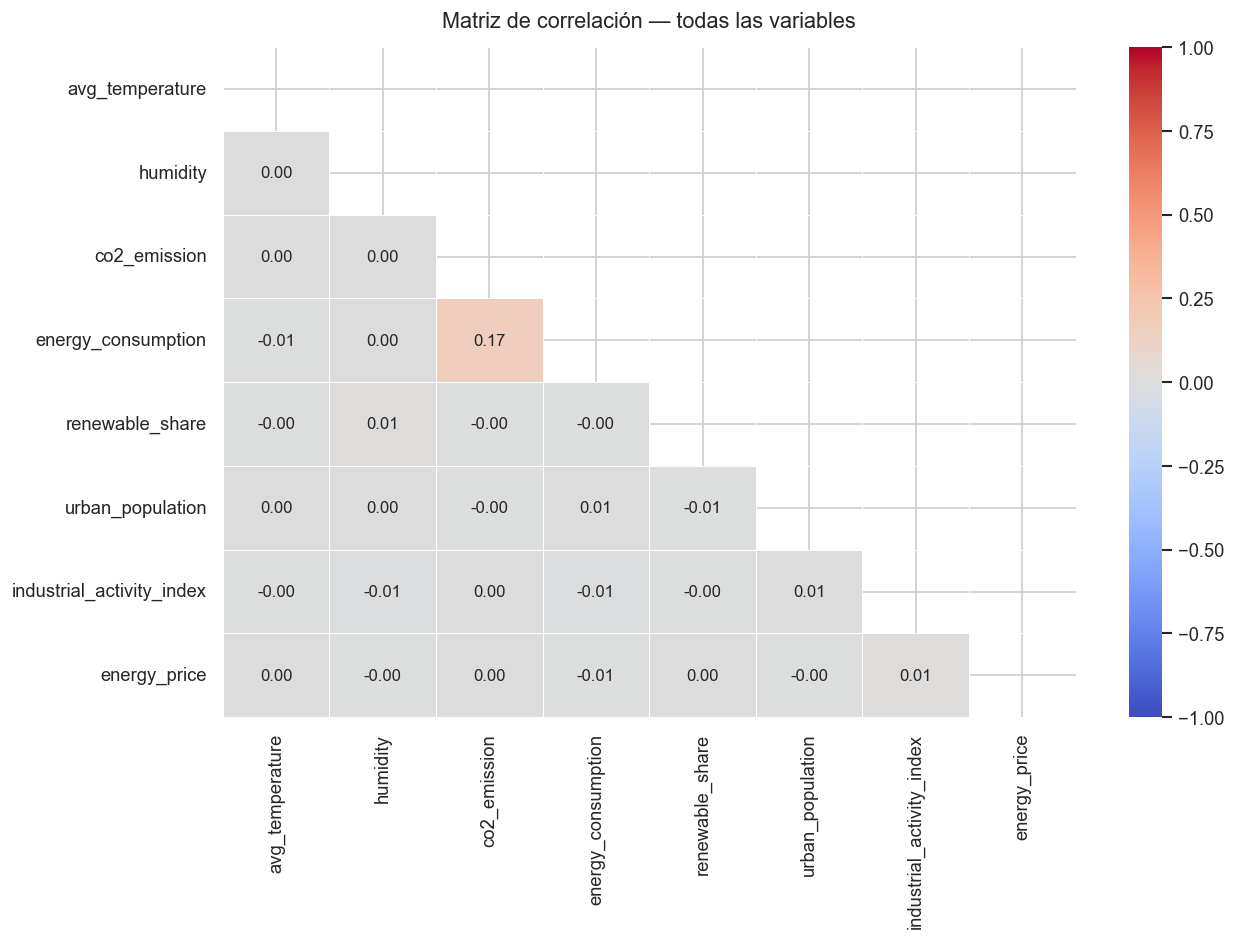

In [10]:
corr = df[variables].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 10}, vmin=-1, vmax=1
)
ax.set_title("Matriz de correlación — todas las variables", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [11]:
X = df[["co2_emission"]]
y = df["energy_consumption"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

modelo = LinearRegression().fit(X_train, y_train)
y_pred = modelo.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_pearson, p_valor = stats.pearsonr(
    df["co2_emission"], df["energy_consumption"])

print("=" * 55)
print("RESULTADOS DEL MODELO DE REGRESIÓN LINEAL")
print("=" * 55)
print(f"  Coeficiente r de Pearson : {r_pearson:.4f}")
print(f"  p-valor                  : {p_valor:.2e}")
print(f"  R²                       : {r2:.4f} ({r2*100:.2f}%)")
print(f"  MAE                      : {mae:.2f}")
print(f"  RMSE                     : {rmse:.2f}")
print(f"  Pendiente                : {modelo.coef_[0]:.4f}")
print(f"  Intercepto               : {modelo.intercept_:.2f}")

RESULTADOS DEL MODELO DE REGRESIÓN LINEAL
  Coeficiente r de Pearson : 0.1718
  p-valor                  : 6.33e-240
  R²                       : 0.0306 (3.06%)
  MAE                      : 3080.24
  RMSE                     : 3652.81
  Pendiente                : 2.6853
  Intercepto               : 6104.76


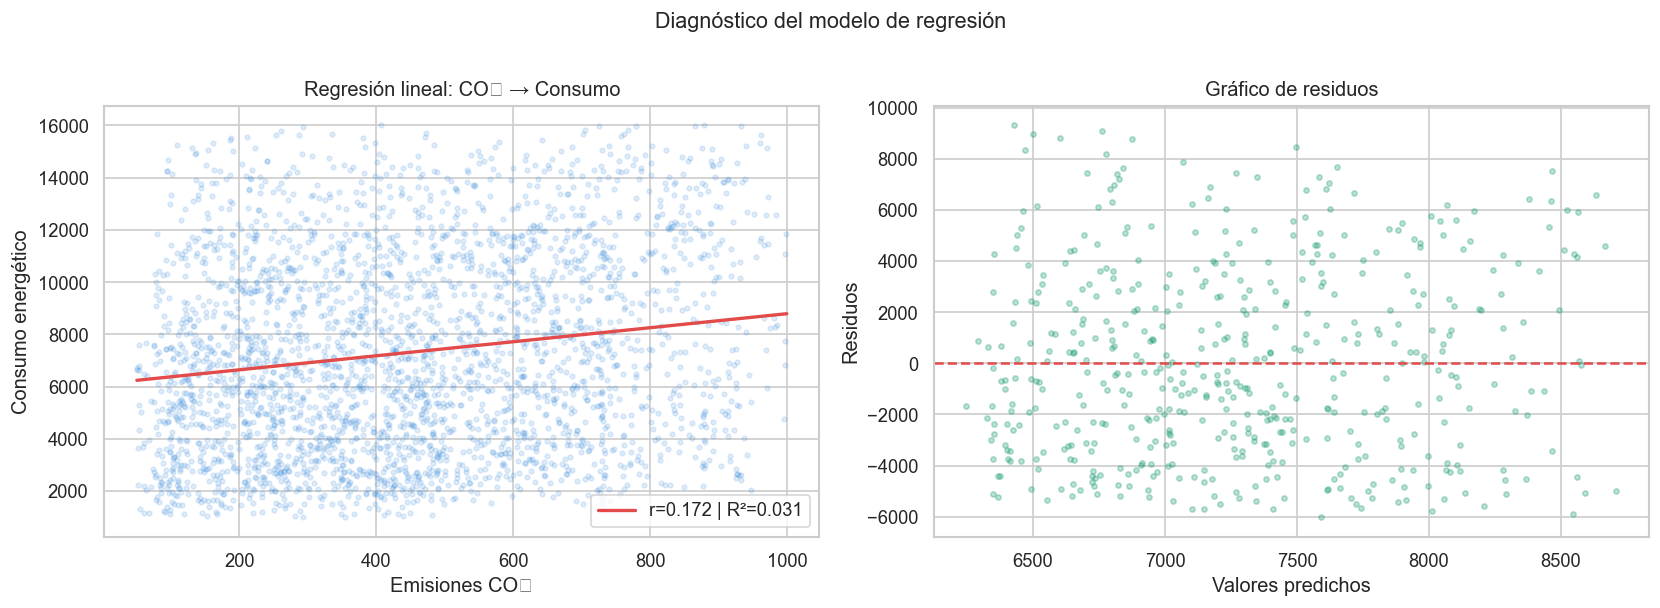

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con línea de regresión
sample = df.sample(3000, random_state=42)
axes[0].scatter(sample["co2_emission"], sample["energy_consumption"],
                alpha=0.15, s=8, color="#378ADD")
x_line = np.linspace(df["co2_emission"].min(),
                     df["co2_emission"].max(), 300)
axes[0].plot(x_line, modelo.coef_[0]*x_line + modelo.intercept_,
             color="#E24B4A", linewidth=2,
             label=f"r={r_pearson:.3f} | R²={r2:.3f}")
axes[0].set_xlabel("Emisiones CO₂")
axes[0].set_ylabel("Consumo energético")
axes[0].set_title("Regresión lineal: CO₂ → Consumo")
axes[0].legend()

# Residuos
residuos = np.array(y_test) - y_pred
idx = np.random.choice(len(residuos), 500, replace=False)
axes[1].scatter(y_pred[idx], residuos[idx],
                alpha=0.3, s=10, color="#1D9E75")
axes[1].axhline(0, color="#E24B4A", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Valores predichos")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Gráfico de residuos")

plt.suptitle("Diagnóstico del modelo de regresión", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Conclusiones y hallazgos finales
<a id="seccion6"></a>

### Hallazgos principales

| Dimensión | Hallazgo | Valor real |
|---|---|---|
| Temperatura | Asia-Pacifico lidera en calor | Promedio global 13.58°C |
| CO₂ | Sin tendencia clara a la baja | Promedio global 445.82 |
| Renovables | Gran brecha entre países | Rango 5% – 30.87% |
| Correlación | Solo CO₂ vs consumo es significativa | r = 0.1718, p ≈ 0.0000 |
| Regresión | Modelo explica poco la varianza | R² = 3.06% |
| Dataset | Naturaleza sintética confirmada | Correlaciones uniformes |

### Limitaciones del dataset
- El dataset fue generado sintéticamente — las variables son
  estadísticamente independientes entre sí por diseño.
- Las correlaciones casi nulas entre la mayoría de variables
  no reflejan la realidad del clima y la energía global.
- Para análisis reales se recomiendan fuentes como
  **NASA GISS**, **IEA** o **Our World in Data**.

### Competencias demostradas
- Limpieza y exploración de datos con **Pandas**
- Estadística descriptiva e inferencial con **SciPy**
- Visualización interactiva con **Plotly** y **Seaborn**
- Regresión lineal y evaluación de modelos con **Scikit-learn**
- Gestión de base de datos relacional con **MySQL**
- Documentación técnica en **Jupyter Notebook**

### Próximos pasos del proyecto
- Paso 7 → Documento teórico en PDF
- Paso 8 → Presentación .pptx
- Paso 9 → Landing page
- Paso 10 → Prototipo Streamlit